In [87]:
import cv2
import os
import matplotlib.pyplot as plt

In [88]:
ROOT_DIR = "C:\\Adrianov\\Projects\\Project-Satanael\\"
DEMO_DIR = os.path.join(ROOT_DIR, 'attack_demo')
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'Test')
SEG_RES_DIR = os.path.join(ROOT_DIR, 'results_segment_grey')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')

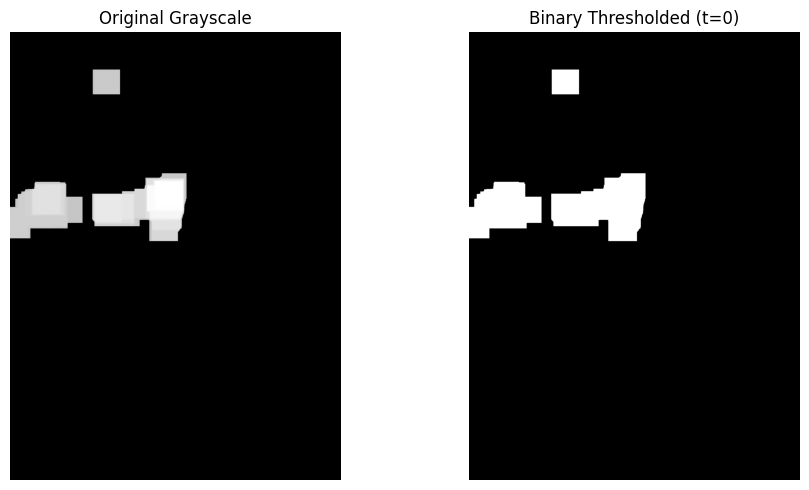

In [90]:
impath = os.path.join(SEG_RES_DIR, 'frc10_10.jpg_h_t_o_c_o.png')
img = cv2.imread(impath, cv2.IMREAD_GRAYSCALE)
_, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Grayscale')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Binary Thresholded (t=0)')
plt.imshow(binary_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [91]:
os.makedirs(MASK_RES_DIR, exist_ok=True)
for filename in os.listdir(SEG_RES_DIR):
    if filename.lower().endswith(("_h_t_o_c_o.png")):
        input_path = os.path.join(SEG_RES_DIR, filename)
        
        # Read as grayscale
        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Failed to read {input_path}")
            continue
        
        # Apply binary threshold with t = 0
        _, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY)

        # Save the result
        output_path = os.path.join(MASK_RES_DIR, filename)
        cv2.imwrite(output_path, binary_img)
        print(f"Processed and saved: {output_path}")

Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_10.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_11.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_12.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_13.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_14.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_15.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_16.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_4.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_6.jpg_h_t_o_c_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\frc10_7.jpg_h_t_o_c_o.png
Processed and

In [31]:
MASKED_DIR = os.path.join(ROOT_DIR, 'masked')

# Ensure output directory exists
os.makedirs(MASKED_DIR, exist_ok=True)

for filename in os.listdir(APRICOT_TEST_DIR):
    if not filename.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    # Base name without extension
    name, ext = os.path.splitext(filename)

    # Expected mask filename
    mask_filename = name + ".jpg_h_t_o_c_o.png"
    mask_path = os.path.join(MASK_RES_DIR, mask_filename)

    if not os.path.exists(mask_path):
        print(f"Mask not found for {filename}, skipping.")
        continue

    # Load RGB image
    img_path = os.path.join(APRICOT_TEST_DIR, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to read image: {img_path}")
        continue

    # Load binary mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Failed to read mask: {mask_path}")
        continue

    # Apply mask: keep only pixels where mask == 255
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # Save result
    output_path = os.path.join(MASKED_DIR, filename)
    cv2.imwrite(output_path, masked_img)
    print(f"Masked and saved: {output_path}")

Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_10.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_11.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_12.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_13.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_14.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_15.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_16.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_4.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_6.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_7.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc10_9.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc1_0.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\frc1_1.jpg
Masked and saved: C:

In [92]:
import os
import cv2
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'test_PAD')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')

def resize_all_masks():
    for fname in os.listdir(MASK_RES_DIR):
        if not fname.endswith('.png'):
            continue

        mask_path = os.path.join(MASK_RES_DIR, fname)

        # Extract base image name (e.g., 'frc1_3.jpg') from mask filename
        base_name = fname.split('_h_t_o_c_o')[0]
        original_path = os.path.join(APRICOT_TEST_DIR, base_name)

        # Load the original image to get its size
        original_img = cv2.imread(original_path)
        if original_img is None:
            print(f'[Warning] Original image not found: {original_path}')
            continue

        h, w = original_img.shape[:2]

        # Load the mask (grayscale)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f'[Warning] Could not load mask: {mask_path}')
            continue

        # Resize mask to match original image size
        resized_mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # Overwrite original mask with resized version
        cv2.imwrite(mask_path, resized_mask)
        print(f'[Info] Resized and saved: {fname}')


In [93]:
resize_all_masks()

[Info] Resized and saved: frc10_10.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_11.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_12.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_13.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_14.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_15.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_16.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_4.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_6.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_7.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_9.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_0.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_1.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_10.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_11.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_12.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_14.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_15.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_16.jpg_h_t_o_c_o.png
[Info] 

In [40]:
import os
import cv2
import numpy as np

OVERLAY_RES_DIR =  os.path.join(ROOT_DIR, 'results_overlay')

import cv2
import numpy as np
import json

def apply_mask_and_draw_boxes(annotation_path, target_category_id):
    os.makedirs(OVERLAY_RES_DIR, exist_ok=True)

    # Load COCO annotation file
    with open(annotation_path, 'r') as f:
        coco = json.load(f)

    # Build mappings
    from collections import defaultdict
    ann_by_image = defaultdict(list)
    for ann in coco['annotations']:
        ann_by_image[ann['image_id']].append(ann)

    filename_to_id = {img['file_name']: img['id'] for img in coco['images']}

    # Process each image
    for fname in os.listdir(APRICOT_TEST_DIR):
        if not fname.endswith('.jpg'):
            continue

        image_path = os.path.join(APRICOT_TEST_DIR, fname)
        mask_name = fname.replace('.jpg', '.jpg_h_t_o_c_o.png')
        mask_path = os.path.join(MASK_RES_DIR, mask_name)

        if not os.path.exists(mask_path):
            print(f'[Skip] No mask for {fname}')
            continue

        image_id = filename_to_id.get(fname)
        if image_id is None:
            print(f'[Skip] No image entry for {fname}')
            continue

        anns = [a for a in ann_by_image[image_id] if a['category_id'] == target_category_id]
        if not anns:
            print(f'[Skip] No annotations for category {target_category_id} in {fname}')
            continue

        # Load image and mask
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            print(f'[Warning] Could not load image or mask for {fname}')
            continue

        if mask.shape != image.shape[:2]:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Apply mask to image (keep only visible regions)
        masked_image = np.zeros_like(image)
        mask_binary = mask > 0
        masked_image[mask_binary] = image[mask_binary]

        # Draw bounding boxes from original image (regardless of mask)
        for ann in anns:
            x, y, w, h = ann['bbox']
            pt1 = (int(x), int(y))
            pt2 = (int(x + w), int(y + h))
            cv2.rectangle(masked_image, pt1, pt2, color=(0, 255, 0), thickness=2)

        # Save result
        save_path = os.path.join(OVERLAY_RES_DIR, fname)
        cv2.imwrite(save_path, masked_image)
        print(f'[Saved] {save_path}')


In [41]:
annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
apply_mask_and_draw_boxes(annot_path, 12)

[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_10.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_11.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_12.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_13.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_14.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_15.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_16.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_4.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_6.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_7.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_9.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc1_0.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc1_1.jpg
[Saved] C:\Adrianov\Projects\Proj

## Calculate Recall value of Segmentation

In [94]:
import json
import numpy as np
import cv2
import skimage.measure as skms


def get_regions_from_mask(mask, min_area=60):
    """Extract connected regions from a binary mask."""
    label = skms.label(mask)
    props = skms.regionprops(label)
    
    regions = []
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            region_mask = (label == i + 1).astype(np.uint8)
            regions.append({
                'mask': region_mask,
                'bbox': prop.bbox,
                'area': prop.area
            })
    return regions

In [95]:
def calculate_iou(region_mask, bbox, epsilon=1e-8):
    """Compute IoU between a region mask and a COCO-style bbox, avoiding division by zero."""
    x1, y1, w, h = bbox
    x1, y1, x2, y2 = int(x1), int(y1), int(x1 + w), int(y1 + h)

    bbox_mask = np.zeros_like(region_mask, dtype=np.uint8)
    bbox_mask[y1:y2, x1:x2] = 1

    intersection = np.logical_and(region_mask, bbox_mask).sum()
    union = np.logical_or(region_mask, bbox_mask).sum()

    return intersection / (union + epsilon)

In [96]:
def match_region(region_mask, anns, threshold=0.5):
    """Check if region matches any annotation (IoU ≥ threshold)."""
    for ann in anns:
        iou = calculate_iou(region_mask, ann['bbox'])
        if iou >= threshold:
            return True
    return False



In [97]:
def tally_true_positive(
    coco_annotation_path, image_filename, category_id, mask, threshold=0.5
):
    """Given an image name and mask, return label (1/0) for each region in the mask."""

    with open(coco_annotation_path, 'r') as f:
        coco = json.load(f)

    image_id = None
    for img in coco['images']:
        if img['file_name'] == image_filename:
            image_id = img['id']
            break

    if image_id is None:
        raise ValueError(f"Image {image_filename} not found in COCO file.")

    anns = [
        ann for ann in coco['annotations']
        if ann['image_id'] == image_id and ann['category_id'] == category_id
    ]
    regions = get_regions_from_mask(mask)
    tp = 0
    fn = 0
    for ann in anns:
        for r in regions:
            if match_region(r['mask'], [ann], threshold):
                tp += 1
                continue
    if tp == 0:
        fn += 1
    return tp, fn

### Recall @IoU=0.5

In [98]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.5
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                                        | 2/875 [00:01<07:23,  1.97it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|█                                                                                                        | 9/875 [00:08<12:52,  1.12it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▍                                                                                                      | 12/875 [00:11<14:44,  1.02s/it]

...

Undetected adversarial patch @sms9_36.jpg


Evaluating images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 864/875 [14:12<00:09,  1.19it/s]

Undetected adversarial patch @sms9_38.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 875/875 [14:20<00:00,  1.02it/s]

Final recall score for segmentation method: 69.41580756013745%


### Recall @IOU=0.40

In [62]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.4
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                        | 2/875 [00:00<05:26,  2.67it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|▉                                                                                        | 9/875 [00:06<09:53,  1.46it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▏                                                                                      | 12/875 [00:08<11:19,  1.27it/s]

...

Undetected adversarial patch @rrs9_9.jpg


Evaluating images:  67%|██████████████████████████████████████████████████████████▌                            | 589/875 [08:16<03:00,  1.58it/s]

Undetected adversarial patch @smc10_0.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 875/875 [08:23<00:00,  1.74it/s]

Undetected adversarial patch @smc10_3.jpg
Final recall score for segmentation method: 71.42857142857143%


### Recall @IOU=0.35

In [99]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.35
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                                        | 2/875 [00:00<06:15,  2.32it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|█                                                                                                        | 9/875 [00:07<10:58,  1.32it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▍                                                                                                      | 12/875 [00:10<12:12,  1.18it/s]

...

Undetected adversarial patch @sms9_36.jpg


Evaluating images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 864/875 [15:13<00:10,  1.06it/s]

Undetected adversarial patch @sms9_38.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 875/875 [15:22<00:00,  1.05s/it]

Final recall score for segmentation method: 76.51775486827033%


### Recall @IOU=0.25

In [100]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.25
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                                        | 2/875 [00:00<06:40,  2.18it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|█                                                                                                        | 9/875 [00:09<14:10,  1.02it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▍                                                                                                      | 12/875 [00:13<18:49,  1.31s/it]

...

Undetected adversarial patch @sms9_36.jpg


Evaluating images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 864/875 [15:53<00:10,  1.05it/s]

Undetected adversarial patch @sms9_38.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 875/875 [16:02<00:00,  1.10s/it]

Final recall score for segmentation method: 79.38144329896907%


### Recall @IOU=0.15

In [101]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.15
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                                        | 2/875 [00:00<06:59,  2.08it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|█                                                                                                        | 9/875 [00:08<12:15,  1.18it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▍                                                                                                      | 12/875 [00:11<14:54,  1.04s/it]

...

Undetected adversarial patch @sms9_36.jpg


Evaluating images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 864/875 [15:15<00:10,  1.06it/s]

Undetected adversarial patch @sms9_38.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 875/875 [15:25<00:00,  1.06s/it]

Final recall score for segmentation method: 83.16151202749141%


## Region's area distribution

In [109]:
from tqdm import tqdm
import cv2

all_areas = []

for fname in tqdm(os.listdir(MASK_RES_DIR), desc="Extracting region info..."):
    if not fname.endswith('.png'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, fname)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)

        # --- Resize mask so shorter side = 1024 ---
        h, w = mask.shape
        if h < w:
            new_h = 1024
            new_w = int(w * (1024 / h))
        else:
            new_w = 1024
            new_h = int(h * (1024 / w))
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    except Exception as e:
        print(f"Error processing {fname}: {e}")
        continue
        
    regions = get_regions_from_mask(mask)
    for r in regions:
        all_areas.append(r['area'])



Extracting region info...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 873/873 [00:44<00:00, 19.52it/s]


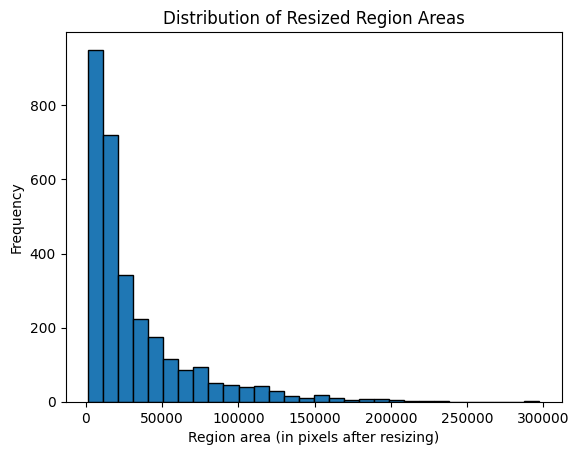

In [110]:
import matplotlib.pyplot as plt

# Plot histogram of resized region areas
plt.hist(all_areas, bins=30, edgecolor='black')
plt.xlabel("Region area (in pixels after resizing)")
plt.ylabel("Frequency")
plt.title("Distribution of Resized Region Areas")
plt.show()

### Feature Extraction

In [1]:
import os

ROOT_DIR = "C:\\Adrianov\\Projects\\Project-Satanael\\"
DEMO_DIR = os.path.join(ROOT_DIR, 'attack_demo')
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'test_PAD')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')
ANNOT_PATH = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")

In [2]:
import sys
import importlib.util
import warnings

color_path = os.path.abspath("../defenselib/feature_extraction/color.py")

spec = importlib.util.spec_from_file_location("color_ext", color_path)
color_ext = importlib.util.module_from_spec(spec)
sys.modules["color_ext"] = color_ext
spec.loader.exec_module(color_ext)


In [3]:
import sys
import importlib.util
import warnings

texture_path = os.path.abspath("../defenselib/feature_extraction/texture.py")

spec = importlib.util.spec_from_file_location("texture_ext", texture_path)
texture_ext = importlib.util.module_from_spec(spec)
sys.modules["texture_ext"] = texture_ext
spec.loader.exec_module(texture_ext)


In [4]:
import json
import numpy as np
import cv2
import skimage.measure as skms


def get_regions_from_mask(mask, min_area=60):
    """Extract connected regions from a binary mask."""
    label = skms.label(mask)
    props = skms.regionprops(label)
    
    regions = []
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            region_mask = (label == i + 1).astype(np.uint8)
            regions.append({
                'mask': region_mask,
                'bbox': prop.bbox,
                'area': prop.area
            })
    return regions
    
def calculate_iou(region_mask, bbox, epsilon=1e-8):
    """Compute IoU between a region mask and a COCO-style bbox, avoiding division by zero."""
    x1, y1, w, h = bbox
    x1, y1, x2, y2 = int(x1), int(y1), int(x1 + w), int(y1 + h)

    bbox_mask = np.zeros_like(region_mask, dtype=np.uint8)
    bbox_mask[y1:y2, x1:x2] = 1
    intersection = np.logical_and(region_mask, bbox_mask).sum()
    union = np.logical_or(region_mask, bbox_mask).sum()
    # print("Intersection", intersection)
    # print("Union", union)
    return intersection / (union + epsilon)
                          
def match_region(region_mask, anns, threshold=0.5):
    """Check if region matches any annotation (IoU ≥ threshold)."""
    for ann in anns:
        iou = calculate_iou(region_mask, ann['bbox'])
        # print("IoU", iou)
        if iou >= threshold:
            return True
    return False



#### Feature Extraction @IOU=0.5

In [5]:
import skimage.measure as skms
from tqdm import tqdm
import pandas as pd

BINS = 32
THRESHOLD = 0.2
RESIZE = 1024
COL_BINS = True
COL_MOMENTS = True
COL_GLCM = True
COL_GABOR = False
DISTS = [1,2,4,8,16,32,64]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GABOR_FREQS = [0.1, 0.2, 0.3, 0.4]

with open(ANNOT_PATH, 'r') as f:
    coco = json.load(f)
    
col_names = ["image_name", "region_id", "area"]

if COL_BINS:
    col_names += [f"rgb_R_bin{i}" for i in range(BINS)] + \
                [f"rgb_G_bin{i}" for i in range(BINS)] + \
                [f"rgb_B_bin{i}" for i in range(BINS)] + \
                [f"hsv_H_bin{i}" for i in range(BINS)] + \
                [f"hsv_S_bin{i}" for i in range(BINS)] + \
                [f"hsv_V_bin{i}" for i in range(BINS)]
if COL_MOMENTS:
    col_names += (
        [f"rgb_R_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"rgb_G_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"rgb_B_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_H_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_S_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_V_{stat}" for stat in ["mean", "std", "skew"]]
    )


df_features = pd.DataFrame(columns=col_names)

glcm_extended = False
adv_extended = False
gabor_extended = False

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Extracting color feature..."):
    if not fname.endswith('.jpg'):
        continue

    image = cv2.imread(os.path.join(APRICOT_TEST_DIR, fname))
    
    h, w = image.shape[:2]
    
    if h < w:
        new_h = RESIZE
        new_w = int(w * (RESIZE / h))
        scale_x = new_w / w
        scale_y = new_h / h
    else:
        new_w = RESIZE
        new_h = int(h * (RESIZE / w))
        scale_x = new_w / w
        scale_y = new_h / h
    
    # --- Resize image ---
    image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # --- Resize mask ---
    mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.uint8)
    
    # --- Find anns for this image ---
    for img in coco['images']:
        if img['file_name'] == fname:
            image_id = img['id']
            break

    anns = [
        ann for ann in coco['annotations']
        if ann['image_id'] == image_id and ann['category_id'] == 12
    ]
    
    # --- Resize bbox for each annotation ---
    for ann in anns:
        x, y, bw, bh = ann['bbox']
        x *= scale_x
        y *= scale_y
        bw *= scale_x
        bh *= scale_y
        ann['bbox'] = [x, y, bw, bh]        
    regions = get_regions_from_mask(mask)
            
    # print(anns)    
    for ann in anns:
        for r in regions:
            r['adversarial'] = match_region(r['mask'], [ann], THRESHOLD)
    
    feature_list = []
    for region_id, r in enumerate(regions):
        feats = [fname, region_id + 1, r['area']]
    
        if COL_BINS:
            feats.extend(color_ext.extract_color_histograms(image, r['mask'], BINS))
    
        if COL_MOMENTS:
            feats.extend(color_ext.extract_color_moments(image, r['mask']))  

        if COL_GLCM:
            haralick = texture_ext.extract_haralick_features(image, r['mask'], DISTS, ANGLES)
            feats.extend(list(haralick.values()))
            if not glcm_extended:
                col_names.extend(list(haralick.keys()))
                glcm_extended = True
                
        if COL_GABOR:
            gabor_feats = texture_ext.extract_gabor_features(image, r['mask'], GABOR_FREQS, ANGLES)
            feats.extend(list(gabor_feats.values()))
            if not gabor_extended:
                col_names.extend(list(gabor_feats.keys()))
                gabor_extended = True
                
        feats.append(r['adversarial'])
        feature_list.append(feats)

    if not adv_extended:
        col_names += ["adversarial"]
        adv_extended = True
    # print(col_names)
    df = pd.DataFrame(feature_list, columns=col_names)
    df_features = pd.concat([df_features, df], ignore_index=True)


Extracting color feature...:   0%|                                                                                       | 0/875 [00:00<?, ?it/s]C:\Users\adria\AppData\Local\Temp\ipykernel_23976\510971869.py:131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_features = pd.concat([df_features, df], ignore_index=True)
Extracting color feature...:  21%|████████████████▎                                                            | 186/875 [08:08<24:28,  2.13s/it]C:\Users\adria\AppData\Local\Temp\ipykernel_23976\510971869.py:131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retai

In [6]:
df_features

,image_name,region_id,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,...,ASM_dist16_135deg,ASM_dist32_0deg,ASM_dist32_45deg,ASM_dist32_90deg,ASM_dist32_135deg,ASM_dist64_0deg,ASM_dist64_45deg,ASM_dist64_90deg,ASM_dist64_135deg,adversarial
0,frc10_10.jpg,1,8585.0,266,888,911,679,575,540,523,...,0.988562,0.986952,0.986333,0.987689,0.986333,0.982848,0.982891,0.984462,0.982891,False
1,frc10_10.jpg,2,53067.0,3779,4347,3834,3843,3827,3841,3726,...,0.937118,0.931812,0.928507,0.932988,0.930490,0.919895,0.915381,0.921784,0.919026,False
2,frc10_10.jpg,3,37006.0,3644,3842,3334,2970,2986,2884,2696,...,0.957170,0.956586,0.952546,0.952295,0.954621,0.953884,0.947560,0.943642,0.951435,False
3,frc10_11.jpg,1,22900.0,1258,2799,2941,2083,1439,1124,822,...,0.971709,0.968434,0.967519,0.970728,0.967649,0.960845,0.960423,0.965988,0.960601,False
4,frc10_11.jpg,2,12142.0,0,0,1,10,21,54,106,...,0.984336,0.982690,0.981523,0.982965,0.981598,0.978091,0.977044,0.978779,0.977121,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2985,sms9_9.jpg,1,46768.0,0,0,1,19,58,186,316,...,0.926550,0.922013,0.918264,0.922624,0.918301,0.909102,0.903241,0.910556,0.903424,True
2986,sms9_9.jpg,2,6418.0,2,28,119,254,477,577,427,...,0.990050,0.990543,0.989327,0.987960,0.989494,0.990229,0.989279,0.984946,0.989451,False
2987,sms9_9.jpg,3,8260.0,0,0,0,5,16,41,53,...,0.985317,0.983661,0.982385,0.983558,0.982376,0.978813,0.977817,0.978683,0.977808,False
2988,sms9_9.jpg,4,16326.0,0,0,6,47,102,133,196,...,0.974425,0.974376,0.970485,0.969516,0.972326,0.973120,0.965953,0.961929,0.969448,False


In [7]:
df_features["adversarial"].value_counts()

adversarial
False    2281
True      709
Name: count, dtype: int64

In [9]:
OUTPUT_CSV = "features_nogabor_iou20.csv"
df_features.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved color features to {OUTPUT_CSV} with {len(df_features)} rows")

✅ Saved color features to features_nogabor_iou20.csv with 2990 rows
